# Linear Algebra and Dynamics

Graduate Quantitative Economics and Datascience

Jesse Perla (University of British Columbia)

# Overview

## Motivation and Materials

- This lecture applies the tools from the previous one to dynamics in economics and datascience
  - Eigendecompositions to compute matrix powers, and hence the trajectories of linear difference equations
  - Steady states as fixed points, found from eigenvectors or with `solve`
  - The Neumann series for present discounted values of a stream of payoffs
  - Eigenvectors for the long-run distribution of workers across employment states and of clicks across web pages
  - An optional section on linearizing nonlinear dynamics around a steady state
- The goal is to sharpen your intuition on linear algebra and practice some basic coding

## Extra Materials

- Material related to: [QuantEcon Python](https://python.quantecon.org/linear_algebra.html), [QuantEcon Data Science](https://datascience.quantecon.org/scientific/applied_linalg.html), [Intro Quantitative Economics with Python](https://intro.quantecon.org/)
- **Self-study and Optional Materials:**
  - [Geometric Series and Present Values](https://intro.quantecon.org/geom_series.html#example-interest-rates-and-present-values)
  - [Unemployment Dynamics example](https://datascience.quantecon.org/scientific/applied_linalg.html#unemployment-dynamics)
  - [Supply and Demand](https://intro.quantecon.org/intro_supply_demand.html)
  - [More on Competitive Equilibrium](https://intro.quantecon.org/supply_demand_multiple_goods.html)
- **For the optional section:** [Dynamics and Stability in One Dimension](https://intro.quantecon.org/scalar_dynam.html), the [Solow-Swan Model](https://intro.quantecon.org/solow.html) (skip 20.3), and [first-order Taylor expansions](https://en.wikipedia.org/wiki/Linearization#Multivariable_functions)

## Packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import matrix_power
from scipy.linalg import inv, solve, eig, eigvals

# Matrix Powers and Eigendecompositions

## Matrix Powers via the Eigendecomposition

- Iterating a linear map means computing $A^t = A \cdot A \cdots A$ for large $t$
- With the eigendecomposition $A = Q \Lambda Q^{-1}$ the $Q^{-1} Q$ pairs in the middle cancel

$$
A^t = Q \Lambda^t Q^{-1},\quad \Lambda^t = \mathrm{diag}(\lambda_1^t, \ldots, \lambda_N^t)
$$

- Eigenvalues are complex in general. Here they are real, so we drop the zero imaginary parts

In [3]:
A = np.array([[0.9, 0.1],
              [0.5, 0.8]])
Lambda, Q = eig(A)
Lambda = np.real(Lambda)
t = 10
A_t = Q @ np.diag(Lambda**t) @ inv(Q)
print(f"Lambda = {Lambda}")
print(f"Q Lambda^t Q^-1 =\n{A_t}")
print(f"same as A^t? \
{np.allclose(A_t, matrix_power(A, t))}")

Lambda = [1.07912878 0.62087122]
Q Lambda^t Q^-1 =
[[1.30777807 0.46547202]
 [2.3273601  0.84230605]]
same as A^t? True

# Difference Equations

## Linear Difference Equations as Iterative Maps

- Consider $A : {\mathbb{R}}^N \to {\mathbb{R}}^N$ as the linear map for the state $x_t \in {\mathbb{R}}^N$
- An example of a linear difference equation is

$$
x_{t+1} = A x_t,\quad
A \equiv \begin{bmatrix}
0.9 & 0.1 \\
0.5 & 0.8 \\
\end{bmatrix}
$$

In [4]:
x_0 = np.array([1, 1])
x_1 = A @ x_0
print(f"x_1 = {x_1}, x_2 = {A @ x_1}")

x_1 = [1.  1.3], x_2 = [1.03 1.54]

## Iterating with ${\varrho\!\left( {A} \right)} > 1$

Iterate $x_{t+1} = A x_t$ from $x_0$ for $t=200$

In [5]:
x_0 = np.array([1, 1])
t = 200
x_t = matrix_power(A, t) @ x_0
rho_A = np.max(np.abs(eigvals(A)))
print(f"rho(A) = {rho_A}")
print(f"x_{t} = {x_t}")

rho(A) = 1.079128784747792
x_200 = [3406689.32410673 6102361.18640516]

- Diverges to $x_{\infty} = \begin{bmatrix} \infty & \infty \end{bmatrix}^{\top}$
- ${\varrho\!\left( {A} \right)} = 1 + 0.079$ says in the worst case (i.e., $x_t \propto$ the eigenvector associated with $\lambda = 1.079$ eigenvalue), expands by $7.9\%$ on each iteration

## Iterating with ${\varrho\!\left( {A} \right)} < 1$

In [6]:
A = np.array([[0.6, 0.1],
              [0.5, 0.8]])
x_t = matrix_power(A, t) @ x_0
rho_A = np.max(np.abs(eigvals(A)))
print(f"rho(A) = {rho_A}")
print(f"x_{t} = {x_t}")

rho(A) = 0.9449489742783178
x_200 = [6.03450418e-06 2.08159603e-05]

- Converges to $x_{\infty} = \begin{bmatrix} 0 & 0 \end{bmatrix}^{\top}$

## Eigenvalues Decompose the Dynamics

- The eigenvectors form a basis here, so $x_0 = c_1 q_1 + c_2 q_2$ for $c = Q^{-1} x_0$
- Then $x_t = A^t x_0 = c_1 \lambda_1^t q_1 + c_2 \lambda_2^t q_2$: each eigenvector direction scales by its own $\lambda_i^t$
  - ${\varrho\!\left( {A} \right)}$ is the fastest-growing direction: $> 1$ explodes, $< 1$ decays
  - The smaller $|\lambda_i|$ is the transient, and its eigenvalue is its decay rate

In [7]:
Lambda, Q = eig(A)
Lambda = np.real(Lambda)
c = solve(Q, x_0) # x_0 = Q c
t = 10
x_t = Q @ (c * Lambda**t)
print(f"Lambda = {Lambda}")
print(f"c = {c}")
print(f"x_{t} = {x_t}")
print(f"same as A^t x_0? \
{np.allclose(x_t, matrix_power(A, t) @ x_0)}")

Lambda = [0.45505103 0.94494897]
c = [-0.88048573 -1.79575746]
x_10 = [0.28401728 0.97878213]
same as A^t x_0? True

# Steady States and Fixed Points

## Affine Difference Equations

- Add a constant: $x_{t+1} = A x_t + b$ for $b \in {\mathbb{R}}^N$
- A steady state $x^*$ satisfies $x^* = A x^* + b$, i.e. $(I - A) x^* = b$, a linear system for `solve`
- Deviations $\hat{x}_t \equiv x_t - x^*$ follow the homogeneous equation

$$
\hat{x}_{t+1} = A x_t + b - (A x^* + b) = A \hat{x}_t,\quad\text{so}\quad \hat{x}_t = A^t \hat{x}_0
$$

- Hence $x_t \to x^*$ from any $x_0$ if and only if ${\varrho\!\left( {A} \right)} < 1$

In [8]:
b = np.array([1.0, 1.0])
x_star = solve(np.eye(2) - A, b)
x = np.array([1.0, 1.0])
T = 200
for _ in range(T):
    x = A @ x + b
print(f"x_star = {x_star}")
print(f"x_{T} = {x}")

x_star = [10. 30.]
x_200 = [ 9.99989642 29.99964269]

## Fixed Points

> **Fixed Point**
>
> Let $f : S \to S$ for $S \subseteq {\mathbb{R}}^N$. A fixed point $x^* \in S$ of $f$ is one where
>
> $$
> x^* = f(x^*)
> $$
>
> Fixed points may not exist, or there may be several.

- The steady state $x^* = (I - A)^{-1} b$ is the fixed point of the affine map $f(x) = A x + b$
- The linear map $f(x) = A x$ always has the fixed point $x^* = 0$
  - It has others if and only if $\lambda = 1$ is an eigenvalue: every point on that eigenvector satisfies $A x^* = x^*$
  - The next two sections are exactly this case

## The Neumann Series

> **Neumann Series**
>
> If ${\varrho\!\left( {A} \right)} < 1$ then $I - A$ is invertible and $(I - A)^{-1} = \sum_{s=0}^{\infty} A^s = I + A + A^2 + \ldots$

- The matrix version of $\sum_{s=0}^{\infty} a^s = \frac{1}{1-a}$ for $|a| < 1$
- Iterating the affine equation reaches the same steady state as `solve`: $x_t = A^t x_0 + \sum_{s=0}^{t-1} A^s b \to (I - A)^{-1} b = x^*$
- Present discounted values below are the same series with $\beta A$ in place of $A$

In [9]:
A_sum = sum(matrix_power(A, s) for s in range(500))
print(f"sum of A^s =\n{A_sum}")
print(f"inv(I - A) =\n{inv(np.eye(2) - A)}")

sum of A^s =
[[ 6.66666667  3.33333333]
 [16.66666667 13.33333333]]
inv(I - A) =
[[ 6.66666667  3.33333333]
 [16.66666667 13.33333333]]

# Unemployment Dynamics

## Dynamics of Employment without Population Growth

- Consider an economy where in a given year $\alpha = 5\%$ of employed workers lose job and $\phi = 10\%$ of unemployed workers find a job
- We start with $E_0 = 900,000$ employed workers, $U_0 = 100,000$ unemployed workers, and no birth or death. Dynamics for the year:

$$
\begin{aligned}
E_{t+1} &= (1-\alpha) E_t + \phi U_t\\
U_{t+1} &= \alpha E_t + (1-\phi) U_t
\end{aligned}
$$

## Flows Between Employment and Unemployment

- A fraction $\alpha$ of the employed lose their job and $\phi$ of the unemployed find one each year
- The same two-state structure returns as a Markov chain in the optional stochastic processes deck

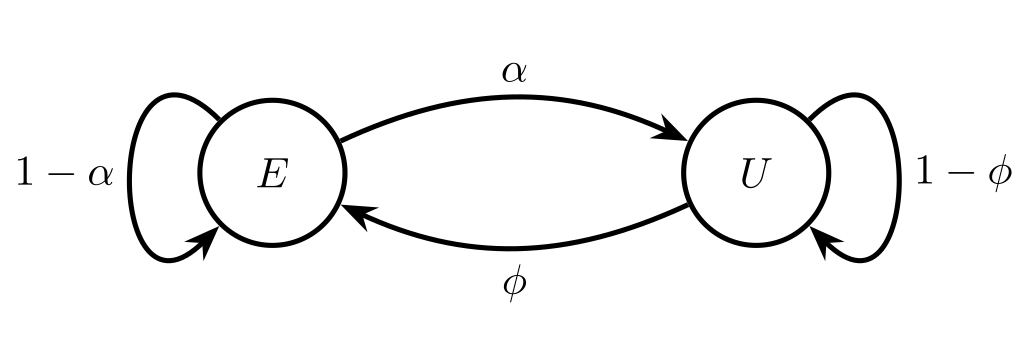

## Write as Linear System

- Use matrices and vectors to write as a linear system

$$
\underbrace{\begin{bmatrix} E_{t+1}\\U_{t+1}\end{bmatrix}}_{X_{t+1}} = \underbrace{\begin{bmatrix} 1-\alpha & \phi \\ \alpha & 1-\phi \end{bmatrix}}_{ A} \underbrace{\begin{bmatrix} E_{t}\\U_{t}\end{bmatrix}}_{X_t}
$$

## Simulating

Simulate by iterating $X_{t+1} = A X_t$ from $X_0$ until $T=100$

In [11]:
def simulate(A, X_0, T):
    X = np.zeros((2, T+1))
    X[:,0] = X_0
    for t in range(T):
        X[:,t+1] = A @ X[:,t]
    return X
X_0 = np.array([900000, 100000])
A = np.array([[0.95, 0.1], [0.05, 0.9]])
T = 100
X = simulate(A, X_0, T)
print(f"X_{T} = {X[:,T]}")

X_100 = [666666.6870779  333333.31292209]

## Dynamics of Unemployment

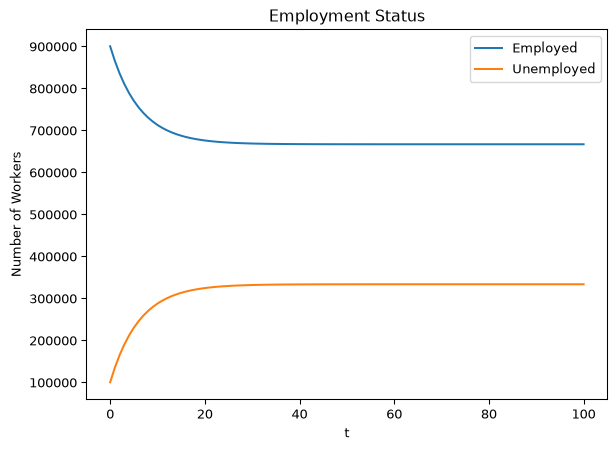

In [12]:
fig, ax = plt.subplots()
ax.plot(range(T+1), X.T,
  label=["Employed", "Unemployed"])
ax.set(xlabel="t",
  ylabel="Number of Workers",
  title="Employment Status")
ax.legend()
plt.show()

## Convergence to a Longrun Distribution

- Find $X_{\infty}$ by iterating $X_{t+1} = A X_t$ many times from a $X_0$?

  - Check if it has converged with $X_{\infty} \approx A X_{\infty}$
  - Is $X_{\infty}$ the same from any $X_0$? The optional stochastic processes deck covers this “ergodicity” question

- Alternatively, note that this expression is the same as

  $$
  1 \times \bar{X} = A \bar{X}
  $$

  - i.e, a $\lambda = 1$ where $\bar{X}$ is the corresponding eigenvector of $A$, a fixed point of the linear map $X \mapsto A X$
  - Is $\lambda = 1$ always an eigenvalue? (yes if all $\sum_{n=1}^N A_{ni} = 1$ for all $i$)
  - Does $\bar{X} = X_{\infty}$? For any $X_0$?
  - Multiple eigenvalues with $\lambda = 1 \implies$ multiple $\bar{X}$

## Using the First Eigenvector for the Steady State

In [13]:
Lambda, Q = eig(A)
print(f"real eigenvalues = {np.real(Lambda)}")
print(f"eigenvectors in columns of =\n{Q}")
print(f"first eigenvalue = 1? \
{np.isclose(Lambda[0], 1.0)}")
X_bar = Q[:,0] / np.sum(Q[:,0]) * np.sum(X_0)
print(f"X_bar = {X_bar}\nX_{T} = {X[:,T]}")

real eigenvalues = [1.   0.85]
eigenvectors in columns of =
[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]
first eigenvalue = 1? True
X_bar = [666666.66666667 333333.33333333]
X_100 = [666666.6870779  333333.31292209]

## Using the Second Eigenvalue for the Convergence Speed

- The second largest ($\lambda_2 < 1$) provides information on the speed of convergence
  - $0$ is instantaneous convergence here
  - $1$ is no convergence here
- We will create a new matrix with the same steady state, different speed
  - To do this, build a new matrix with the same eigenvectors (in particular the same eigenvector associated with the $\lambda=1$ eigenvalue)
  - But we will replace the eigenvalues $\begin{bmatrix}1.0 & 0.85\end{bmatrix}$ with $\begin{bmatrix}1.0 & 0.4\end{bmatrix}$
  - Then we will reconstruct $A$ matrix and simulate again
- Intuitively we will see the that the resulting $A_{\text{fast}}$ implies $\alpha$ and $\phi$ which are larger by the same proportion
- The eigenvector for $\lambda_2$ sums to zero (it moves workers between $E$ and $U$ without changing the total), so $X_t - \bar{X} \propto \lambda_2^t$ times it: the second eigenvector is the direction of the transient

## Simulating with Different Eigenvalues

In [14]:
Lambda_fast = np.array([1.0, 0.4])
A_fast = Q @ np.diag(Lambda_fast) @ inv(Q) # same eigenvectors
print("A_fast =\n", A_fast)
print(f"alpha_fast/alpha = {A_fast[1,0]/A[1,0]:.2g}, \
phi_fast/phi = {A_fast[0,1]/A[0,1]:.2g}")
X_fast = simulate(A_fast, X_0, T)
print(f"X_{T} = {X_fast[:,T]}")

A_fast =
 [[0.8 0.4]
 [0.2 0.6]]
alpha_fast/alpha = 4, phi_fast/phi = 4
X_100 = [666666.66666667 333333.33333333]

## Convergence Dynamics of Unemployment

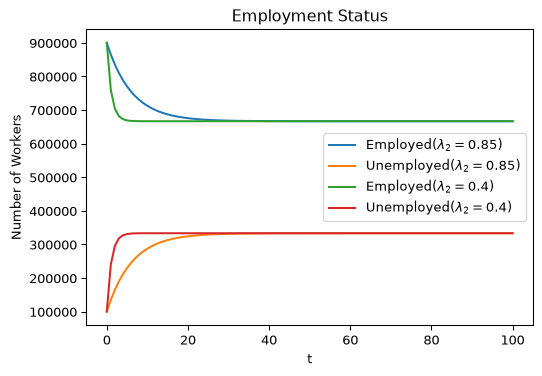

In [15]:
lambda_2_old = np.real(Lambda[1])
lambda_2_new = Lambda_fast[1]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(T+1), X.T, label=[rf"Employed$(\lambda_2={lambda_2_old})$", rf"Unemployed$(\lambda_2={lambda_2_old})$"])
ax.plot(range(T+1), X_fast.T, label=[rf"Employed$(\lambda_2={lambda_2_new})$", rf"Unemployed$(\lambda_2={lambda_2_new})$"])
ax.set(xlabel="t", ylabel="Number of Workers", title="Employment Status")
ax.legend()
plt.show()

# PageRank

## Network of Web Pages

- Consider $A, B, C, D$ as a set of web pages with links given below
- Which page is the most important? $A$ and $C$ each have two links pointing at them

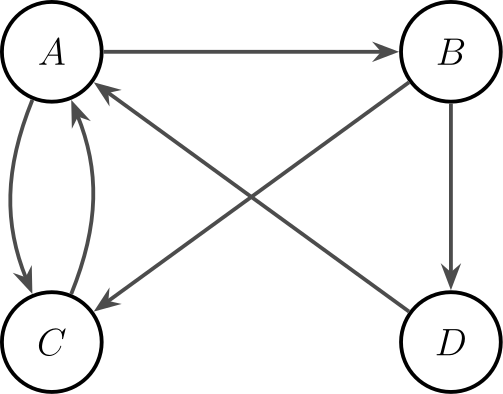

## Create an Adjacency Matrix

- We can summarize the network of web pages with $1$ or $0$ if there is a link between two pages. Pages won’t link to themselves
- Row $i$ is the page you are on, column $j$ is the page linked to, in (arbitrary) order: A, B, C, D

$$
M = \begin{bmatrix}
0 & 1 & 1 & 0 \\
0 & 0 & 1 & 1 \\
1 & 0 & 0 & 0 \\
1 & 0 & 0 & 0
\end{bmatrix}
$$

## PageRank Algorithm

One interpretation of this is that you can

- Start on some page
- With equal probability click on all pages linked at that page
- Keep doing this process and then determine what fraction of time you spend on each page

## Probabilistic Interpretation

Alternatively,

- Start with a probability distribution, $r_t$ that you will be on any given page (i.e. $r_{nt} \geq 0$ and $\sum_{n=1}^4 r_{nt} = 1$)
- Iterate the process to see the probability distribution after you click the next links
- Repeat until the probability distribution doesn’t change.

## Adjacency Matrix to Probabilities

- To implement, we want to put the same probability on going to any link for a given page (i.e. each row)
- Divide each row of $M$ by the number of links on that page, so every row of $S$ sums to one

In [17]:
M = np.array([[0, 1, 1, 0],
              [0, 0, 1, 1],
              [1, 0, 0, 0],
              [1, 0, 0, 0]])
S = M / M.sum(axis=1, keepdims=True)
print(S)

[[0.  0.5 0.5 0. ]
 [0.  0.  0.5 0.5]
 [1.  0.  0.  0. ]
 [1.  0.  0.  0. ]]

## Probabilities Evolution

- For a given $r_t$ distribution of probabilities across pages, the distribution after one more click is

$$
r_{t+1} = S^{\top} r_t
$$

- Same structure as the unemployment dynamics: the columns of $S^{\top}$ sum to one, so $\lambda = 1$ is an eigenvalue and probability mass is conserved
- Starting on page $A$ for certain and iterating, the distribution settles down

In [18]:
r_0 = np.array([1.0, 0.0, 0.0, 0.0])
for T in [1, 2, 5, 20]:
    r_T = matrix_power(S.T, T) @ r_0
    print(f"r_{T} = {np.round(r_T, 4)}")

r_1 = [0.  0.5 0.5 0. ]
r_2 = [0.5  0.   0.25 0.25]
r_5 = [0.5   0.125 0.25  0.125]
r_20 = [0.3994 0.2002 0.3003 0.1001]

## Long-run Distribution and Eigenvectors

- The stationary distribution $\bar{r} = S^{\top} \bar{r}$ is a fixed point of $r \mapsto S^{\top} r$: the eigenvector of $S^{\top}$ with $\lambda = 1$, rescaled to sum to one
- The other eigenvalues have $|\lambda| < 1$, and the largest of them sets the speed of convergence

In [19]:
Lambda, Q = eig(S.T)
i = np.argmin(np.abs(Lambda - 1.0))
r_bar = np.real(Q[:, i])
r_bar = r_bar / np.sum(r_bar)
print(f"|eigenvalues| = {np.round(np.abs(Lambda), 3)}")
print(f"r_bar = {r_bar}")

|eigenvalues| = [1.    0.707 0.707 0.   ]
r_bar = [0.4 0.2 0.3 0.1]

- $A$ outranks $C$ even though both have two incoming links: $C$ and $D$ link only to $A$, while $A$ and $B$ split their links. A link from an important page, or from a page with few links, counts for more

## PageRank at Scale

- The real PageRank is a little more subtle (adds in dampening) but the same basic idea
- With billions of pages, an eigendecomposition is $O(N^3)$ and infeasible
- Iterating $r_{t+1} = S^{\top} r_t$ is $O(N^2)$ per step, and far less since almost every entry of $S$ is zero. Convergence is geometric at the rate of the second largest $|\lambda|$
  - This “power iteration” is exactly what we did by simulating, and is how the eigenvector is found in practice
- Motivation to learn more probability, and Markov chains in the optional stochastic processes deck

# Present Discounted Values

## Basic Asset Pricing

- Deterministic, infinite horizon, risk-neutral asset pricing based on fundamentals
- Present-value of cashflows, dividends, etc.
- Discount factor $\beta \in (0,1)$
  - Might come from consumer impatience, or an internal rate of return
  - Or can get out of risk-free interest rate $r$ as $\beta = \frac{1}{1+r}$ in some cases
- Could price based on fundamentals as:

$$
p_t = \sum_{s=0}^{\infty} \beta^s y_{t+s}
$$

## Scalar Aggregate State

- Assume dividends follow $y_{t+1} = a y_t$ for $t=0,1,\ldots$ and $y_0$ is given

- $a > 0$ shows how period-payoffs evolve. Can only be a growth or shrinkage factor here.

  $$
  p_t = \sum_{s=0}^{\infty} \beta^s y_{t+s} = \frac{y_t}{1-\beta a}
  $$

  - Note that $\beta a < 1$ is required for convergence
  - If $a$ makes dividends grow faster than the discount rate, then the fundamental price is undefined
  - Of course, assets don’t grow forever, but if they grow for a long time this could still be a problem

## Geometric Series for Linear State Space Models

- More generally for vector $x_t\in{\mathbb{R}}^N$ capturing the relevant state of the world for payoff $y_t$:

  - $x_{t+1} = A x_t$ with $y_t = G x_t$
  - $A \in {\mathbb{R}}^{N \times N}$ and $G \in {\mathbb{R}}^{1 \times N}$ then
  - Called a linear state space model

  $$
  \begin{aligned}
  p_t &= y_t + \beta y_{t+1} + \beta^2 y_{t+2} + \ldots = G x_t + \beta G A x_t + \beta^2 G A A  x_t + \ldots\\
  &= G \sum_{s=0}^{\infty} (\beta A)^s x_t = G (I - \beta A)^{-1} x_t
  \end{aligned}
  $$

- The Neumann series with $\beta A$ requires ${\varrho\!\left( {\beta A} \right)} = \beta {\varrho\!\left( {A} \right)} < 1$: the maximum expansion of $A$ in its worst direction must be less than the discounting, or the infinite PDV is not defined

- The scalar case is $A = \begin{bmatrix} a \end{bmatrix}$, $G = \begin{bmatrix} 1 \end{bmatrix}$ and ${\varrho\!\left( {A} \right)} = a$

## PDV Example

Here is an example with $1 < {\varrho\!\left( {A} \right)} < 1/\beta$. Try with different $A$

In [20]:
beta = 0.9
A = np.array([[0.85, 0.1],
              [0.2, 0.9]])
G = np.array([[1.0, 1.0]]) # row vector
x_0 = np.array([1.0, 1.0])
p_t = G @ solve(np.eye(2) - beta * A, x_0)
#p_t = G @ inv(np.eye(2) - beta * A) @ x_0 # alternative
rho_A = np.max(np.abs(eigvals(A)))
print(f"p_t = {p_t[0]:.4g}, spectral radius = {rho_A:.4g}, \
1/beta = {1/beta:.4g}")

p_t = 24.43, spectral radius = 1.019, 1/beta = 1.111

# Linearization and Stability

## Stability of a Fixed Point

- Consider $x_{t+1} = f(x_t)$ for a possibly nonlinear $f : {\mathbb{R}}^N \to {\mathbb{R}}^N$ with a fixed point $x^* = f(x^*)$
- The Jacobian $\nabla f(x^*)$ plays the role of $A$
  - For the affine $f(x) = A x + b$ it is exactly $A$, and $\hat{x}_t \to 0$ from any $\hat{x}_0$ if and only if ${\varrho\!\left( {A} \right)} < 1$
- For nonlinear $f$ the same condition is local: $x^*$ is a **stable** fixed point if ${\varrho\!\left( {\nabla f(x^*)} \right)} < 1$, so small perturbations return to it
  - Necessary but not sufficient globally. ${\varrho\!\left( {\nabla f(x^*)} \right)} > 1 \implies x^*$ can’t be a stable fixed point, but $< 1$ says nothing about starting far away
- You may see this when working with macro models in Dynare and similar methods in macroeconomics

## Linearization

- Assume steady state $x^* = f(x^*)$ exists, with system $x_{t+1} = f(x_t)$
- Take [first-order taylor expansion](https://en.wikipedia.org/wiki/Linearization#Multivariable_functions) around $x^*$

$$
\begin{aligned}
x_{t+1} &= f(x^*) + \nabla f(x^*) (x_t - x^*) + \text{second order and smaller terms}\\
x_{t+1} - x^* &\approx \nabla f(x^*) (x_t - x^*)\\
\hat{x}_{t+1} &\approx \nabla f(x^*) \hat{x}_t
\end{aligned}
$$

- Where the last formulation is common in macroeconomics and time-series econometrics. $\hat{x}_t\equiv x_t - x^*$ is the **deviation from the steady state**
  - For the affine case these are exact, as there are no higher-order terms

## Quality of Linearization

- Gives approximate dynamics for a perturbation close to the steady state
  - May have good approximation far away from $x^*$ if $f(\cdot)$ is close to linear
  - May have terrible approximations close to $x^*$ if $f(\cdot)$ highly nonlinear/asymmetric
  - Often [log-linearization](https://sites.nd.edu/esims/files/2023/05/log_linearization_sp17.pdf) is used instead, which expresses in percent deviation

## Solow-Swan Growth Model

- An early model of economic growth is the [Solow-Swan model](https://intro.quantecon.org/solow.html#the-model). We state it rather than derive it; see the link for where the equations come from
  - $k_t$ is capital per worker and $y_t$ is output per worker
  - $\alpha \in (0,1)$ governs the marginal product of capital
  - $\delta \in (0,1)$ is the depreciation rate, the fraction of machines breaking each year
  - $z > 0$ is total factor productivity (TFP)
  - $s \in (0,1)$ is the fraction of output saved and invested
- Capital follows a nonlinear difference equation

$$
\begin{aligned}
y_t &= z k_t^{\alpha}\\
k_{t+1} &= s y_t + (1-\delta)k_t = s z k_t^{\alpha} + (1-\delta) k_t \equiv g(k_t),\quad \text{ given } k_0
\end{aligned}
$$

## Steady State and Stability of Solow-Swan

- A fixed point solves $k^* = g(k^*)$, so investment exactly replaces depreciation

$$
s z k^{*\alpha} = \delta k^*\quad \implies\quad k^* = \left(\frac{s z}{\delta}\right)^{\frac{1}{1-\alpha}}
$$

- The Jacobian is a scalar here, so its spectral radius is just its absolute value

$$
\begin{aligned}
g'(k^*) &=  \alpha s z k^{*\alpha-1} + 1-\delta,\quad \text{ substitute } s z k^{*\alpha - 1} = \delta\\
&= \alpha \delta + 1 - \delta = 1 - (1-\alpha)\delta \in (0, 1)
\end{aligned}
$$

- Since $\alpha, \delta \in (0,1)$, $k^*$ is locally stable for any $z$ and $s$
- **Aside:** in macroeconomics, industrial organization, etc. this is related to contraction mappings and Blackwell’s condition

## Checking Numerically

In [21]:
z, s, alpha, delta = 2, 0.3, 0.3, 0.4
def g(k):
    return s * z * k**alpha + (1 - delta) * k
k_star = (s * z / delta)**(1 / (1 - alpha))
g_prime = alpha * s * z * k_star**(alpha - 1) + 1 - delta
k = 0.25
for _ in range(10):
    k = g(k)
print(f"k_star = {k_star:.4f}, g(k_star) = {g(k_star):.4f}")
print(f"g'(k_star) = {g_prime:.4f} = {1 - (1 - alpha) * delta:.4f}")
print(f"k_10 = {k:.4f}")

k_star = 1.7847, g(k_star) = 1.7847
g'(k_star) = 0.7200 = 0.7200
k_10 = 1.7053